In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.preprocessing import image as ig
from tensorflow.keras.preprocessing.image import img_to_array
import random

2026-05-22 23:35:44.865089: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
train_dir = '../car_damage_detection/data1a/training'
test_dir = '../car_damage_detection/data1a/validation'

In [3]:
train_data = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.3,
    horizontal_flip = True
) # increasing size of training data

In [4]:
training_set = train_data.flow_from_directory(train_dir, batch_size = 32, target_size = (64,64), class_mode = 'categorical')

Found 1231 images belonging to 2 classes.


In [5]:
test_data = ImageDataGenerator(rescale = 1./255)

In [6]:
testing_set = test_data.flow_from_directory(test_dir, batch_size= 32, target_size= (64,64), class_mode = 'categorical')

Found 2 images belonging to 2 classes.


In [7]:
histories = []

## Defining model callbacks

In [13]:
def defining_model_callbacks():

    checkpoint = ModelCheckpoint(
      '../car_damage_detection/base.model',
      monitor = 'val_accuracy',
      verbose = 1, #level of detalisation
      save_best_only = True,
      mode = 'max', #looking for max val_accuracy
      save_weights_only = False,
      save_frequency= 1
      )

    earlystop = EarlyStopping(
      monitor = 'val_loss',
      min_delta = 0.001, #diference between previous loss and current loss
      patience = 50, #number of epochs
      verbose = 1,
      mode = 'auto'
  )
    callbacks = [checkpoint,earlystop]

def show_final_history(history):
  fig, ax = plt.subplots(1,2,figsize = (15,5))
  ax[0].set_title('loss')
  ax[0].plot(history.epoch,history.history['loss'], label = 'Train loss')
  ax[0].plot(history.epoch,history.history['val_loss'], label = 'Validation loss')

  ax[1].set_title('Accuracy')
  ax[1].plot(history.epoch,history.history['accuracy'], label = 'Train accuracy')
  ax[1].plot(history.epoch,history.history['val_accuracy'], label = 'Validation accuracy')

  ax[0].legend()
  ax[1].legend()


## 1st model

In [14]:
defining_model_callbacks()
opt1 = tf.keras.optimizers.Adam()


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,3,activation = 'relu', input_shape = (64,64,3)),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    #tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(32,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
   # tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(32,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
  #  tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(32,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
   # tf.keras.layers.Dropout(0.3),


    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2,activation = 'sigmoid') #strange that it works with 2 neurons
])

In [ ]:
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_28 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_28 (MaxPooli  (None, 31, 31, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_29 (Conv2D)          (None, 29, 29, 32)        9248      
                                                                 
 max_pooling2d_29 (MaxPooli  (None, 14, 14, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_30 (Conv2D)          (None, 12, 12, 32)        9248      
                                                                 
 max_pooling2d_30 (MaxPooli  (None, 6, 6, 32)         

In [ ]:
model.compile(
    loss = tf.keras.losses.CategoricalCrossentropy(),
    optimizer = opt1,
    metrics = ['accuracy']
)

In [ ]:
history = model.fit(
    training_set,
    epochs = 100,
    steps_per_epoch = len(training_set),
    validation_data = testing_set,
    validation_steps = len(testing_set),
    callbacks = callbacks
)


Epoch 1/100
58/58 [==============================] - ETA: 0s - loss: 0.6908 - accuracy: 0.5065
Epoch 1: val_accuracy did not improve from 0.86087
58/58 [==============================] - 27s 440ms/step - loss: 0.6908 - accuracy: 0.5065 - val_loss: 0.6750 - val_accuracy: 0.6261
Epoch 2/100
58/58 [==============================] - ETA: 0s - loss: 0.6611 - accuracy: 0.6158
Epoch 2: val_accuracy did not improve from 0.86087
58/58 [==============================] - 22s 386ms/step - loss: 0.6611 - accuracy: 0.6158 - val_loss: 0.6674 - val_accuracy: 0.5913
Epoch 3/100
58/58 [==============================] - ETA: 0s - loss: 0.6149 - accuracy: 0.6679
Epoch 3: val_accuracy did not improve from 0.86087
58/58 [==============================] - 24s 421ms/step - loss: 0.6149 - accuracy: 0.6679 - val_loss: 0.6409 - val_accuracy: 0.6674
Epoch 4/100
58/58 [==============================] - ETA: 0s - loss: 0.6020 - accuracy: 0.6750
Epoch 4: val_accuracy did not improve from 0.86087
58/58 [=============

In [99]:
histories.append(history)

In [ ]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

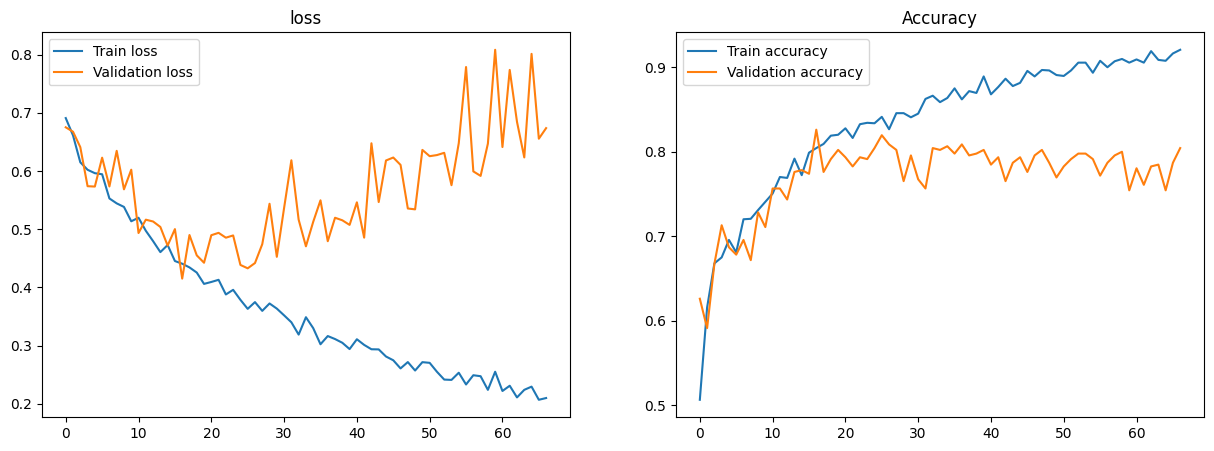

In [ ]:
show_final_history(history)

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/5thProject/model_without_dropouts_sigmoid.keras')

## 2nd model


In [ ]:
defining_model_callbacks()
opt1 = tf.keras.optimizers.Adam()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,3,activation = 'relu', input_shape = (64,64,3)),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(32,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.3),


    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2,activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_32 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_32 (MaxPooli  (None, 31, 31, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_25 (Dropout)        (None, 31, 31, 32)        0         
                                                                 
 conv2d_33 (Conv2D)          (None, 29, 29, 32)        9248      
                                                                 
 max_pooling2d_33 (MaxPooli  (None, 14, 14, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_26 (Dropout)        (None, 14, 14, 32)       

In [ ]:
model.compile(
    loss = tf.keras.losses.CategoricalCrossentropy(),
    optimizer = opt1,
    metrics = ['accuracy']
)

In [ ]:
history2 = model.fit(
    training_set,
    epochs = 100,
    steps_per_epoch = len(training_set),
    validation_data = testing_set,
    validation_steps = len(testing_set),
    callbacks = callbacks
)

Epoch 1/100
58/58 [==============================] - ETA: 0s - loss: 0.7015 - accuracy: 0.4859
Epoch 1: val_accuracy did not improve from 0.86087
58/58 [==============================] - 26s 429ms/step - loss: 0.7015 - accuracy: 0.4859 - val_loss: 0.6927 - val_accuracy: 0.5109
Epoch 2/100
58/58 [==============================] - ETA: 0s - loss: 0.6914 - accuracy: 0.5380
Epoch 2: val_accuracy did not improve from 0.86087
58/58 [==============================] - 29s 499ms/step - loss: 0.6914 - accuracy: 0.5380 - val_loss: 0.6880 - val_accuracy: 0.5522
Epoch 3/100
58/58 [==============================] - ETA: 0s - loss: 0.6764 - accuracy: 0.5609
Epoch 3: val_accuracy did not improve from 0.86087
58/58 [==============================] - 29s 499ms/step - loss: 0.6764 - accuracy: 0.5609 - val_loss: 0.6645 - val_accuracy: 0.6130
Epoch 4/100
58/58 [==============================] - ETA: 0s - loss: 0.6487 - accuracy: 0.6440
Epoch 4: val_accuracy did not improve from 0.86087
58/58 [=============

In [100]:
histories.append(history2)

In [58]:
model.save('../car_damage_detection/base.model/model_2_softmax_64.keras')

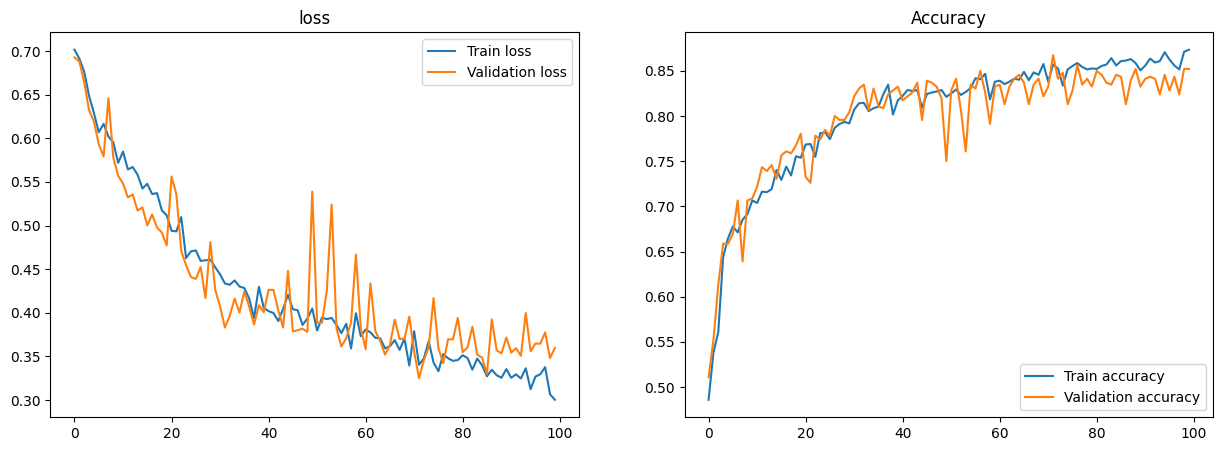

In [59]:
show_final_history(history2)

## 3rd Model

In [90]:
defining_model_callbacks()
opt1 = tf.keras.optimizers.Adam()

In [91]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,3,activation = 'relu', input_shape = (64,64,3)),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(32,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(64,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1,activation = 'sigmoid')
])

In [92]:
model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_48 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_48 (MaxPooli  (None, 31, 31, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_46 (Dropout)        (None, 31, 31, 32)        0         
                                                                 
 conv2d_49 (Conv2D)          (None, 29, 29, 32)        9248      
                                                                 
 max_pooling2d_49 (MaxPooli  (None, 14, 14, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_47 (Dropout)        (None, 14, 14, 32)      

In [93]:
model.compile(
    #loss = tf.keras.losses.CategoricalCrossentropy(),
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = opt1,
    metrics = ['accuracy']
)

In [94]:
history3 = model.fit(
    training_set,
    epochs = 100,
    steps_per_epoch = len(training_set),
    validation_data = testing_set,
    validation_steps = len(testing_set),
    callbacks = callbacks
)

Epoch 1/100
58/58 [==============================] - ETA: 0s - loss: 0.6946 - accuracy: 0.5000
Epoch 1: val_accuracy did not improve from 0.86739
58/58 [==============================] - 27s 420ms/step - loss: 0.6946 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/100
58/58 [==============================] - ETA: 0s - loss: 0.6932 - accuracy: 0.5000
Epoch 2: val_accuracy did not improve from 0.86739
58/58 [==============================] - 26s 447ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/100
58/58 [==============================] - ETA: 0s - loss: 0.6931 - accuracy: 0.5000
Epoch 3: val_accuracy did not improve from 0.86739
58/58 [==============================] - 25s 422ms/step - loss: 0.6931 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/100
58/58 [==============================] - ETA: 0s - loss: 0.6931 - accuracy: 0.5000
Epoch 4: val_accuracy did not improve from 0.86739
58/58 [=============

In [101]:
histories.append(history3)

In [96]:
model.save('../car_damage_detection/base.model/model_3_sigmoid_binary_cross.keras')

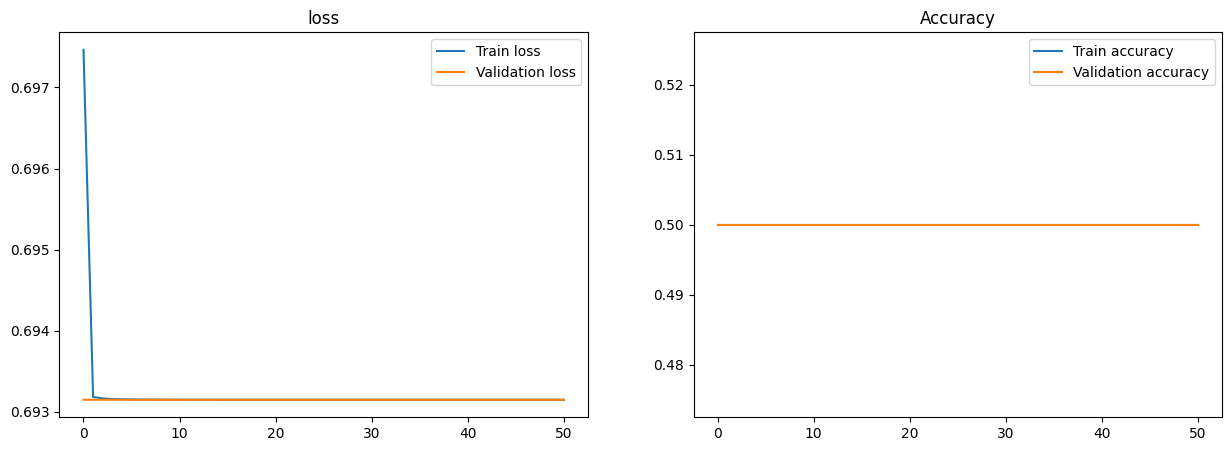

In [83]:
show_final_history(history3)

## 4th model

In [65]:
defining_model_callbacks()
opt1 = tf.keras.optimizers.Adam()

In [66]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,3,activation = 'relu', input_shape = (64,64,3)),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(32,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(64,3,activation = 'relu'),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Dropout(0.4),


    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2,activation = 'softmax')
])

In [67]:
model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_38 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_38 (MaxPooli  (None, 31, 31, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_33 (Dropout)        (None, 31, 31, 32)        0         
                                                                 
 conv2d_39 (Conv2D)          (None, 29, 29, 32)        9248      
                                                                 
 max_pooling2d_39 (MaxPooli  (None, 14, 14, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_34 (Dropout)        (None, 14, 14, 32)      

In [68]:
model.compile(
    loss = tf.keras.losses.CategoricalCrossentropy(),
    optimizer = opt1,
    metrics = ['accuracy']
)

history4 = model.fit(
    training_set,
    epochs = 100,
    steps_per_epoch = len(training_set),
    validation_data = testing_set,
    validation_steps = len(testing_set),
    callbacks = callbacks
)


Epoch 1/100
58/58 [==============================] - ETA: 0s - loss: 0.6989 - accuracy: 0.5348
Epoch 1: val_accuracy did not improve from 0.86739
58/58 [==============================] - 32s 513ms/step - loss: 0.6989 - accuracy: 0.5348 - val_loss: 0.6927 - val_accuracy: 0.5283
Epoch 2/100
58/58 [==============================] - ETA: 0s - loss: 0.6799 - accuracy: 0.5402
Epoch 2: val_accuracy did not improve from 0.86739
58/58 [==============================] - 25s 427ms/step - loss: 0.6799 - accuracy: 0.5402 - val_loss: 0.6745 - val_accuracy: 0.5848
Epoch 3/100
58/58 [==============================] - ETA: 0s - loss: 0.6554 - accuracy: 0.6130
Epoch 3: val_accuracy did not improve from 0.86739
58/58 [==============================] - 25s 430ms/step - loss: 0.6554 - accuracy: 0.6130 - val_loss: 0.6521 - val_accuracy: 0.6109
Epoch 4/100
58/58 [==============================] - ETA: 0s - loss: 0.6312 - accuracy: 0.6446
Epoch 4: val_accuracy did not improve from 0.86739
58/58 [=============

In [102]:
histories.append(history4)

In [69]:
model.save('../car_damage_detection/base.model//model_4_softmax_256.keras')

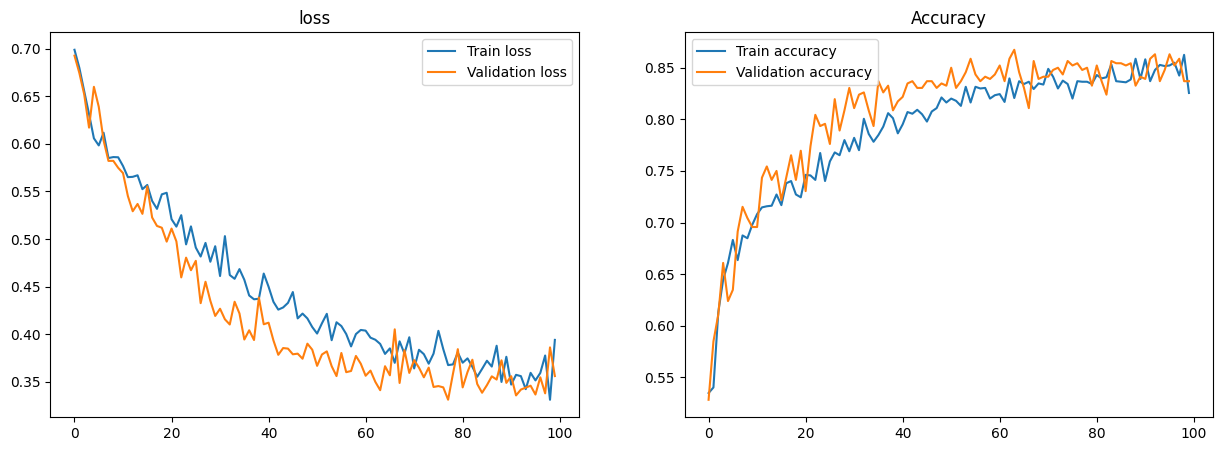

In [70]:
show_final_history(history4)

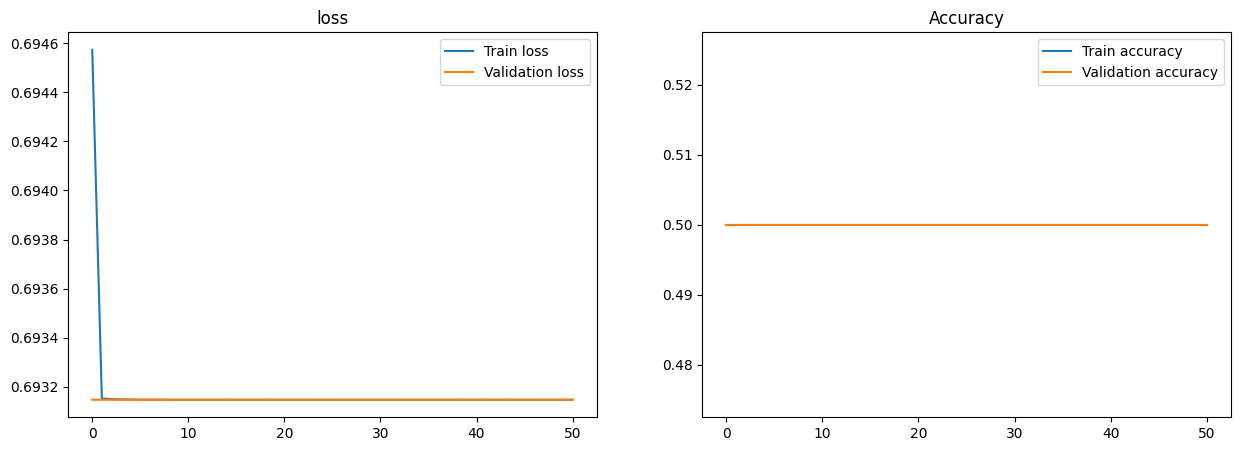

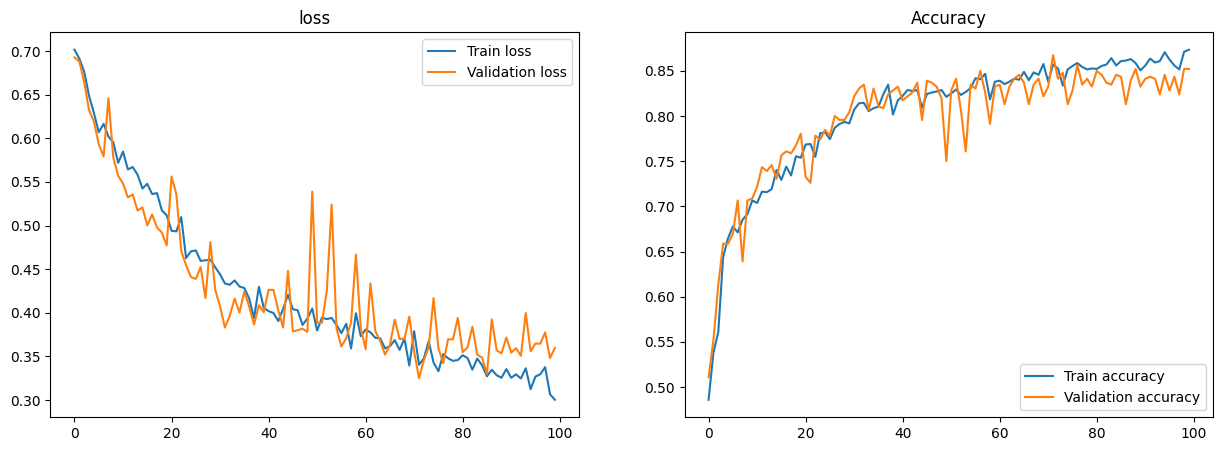

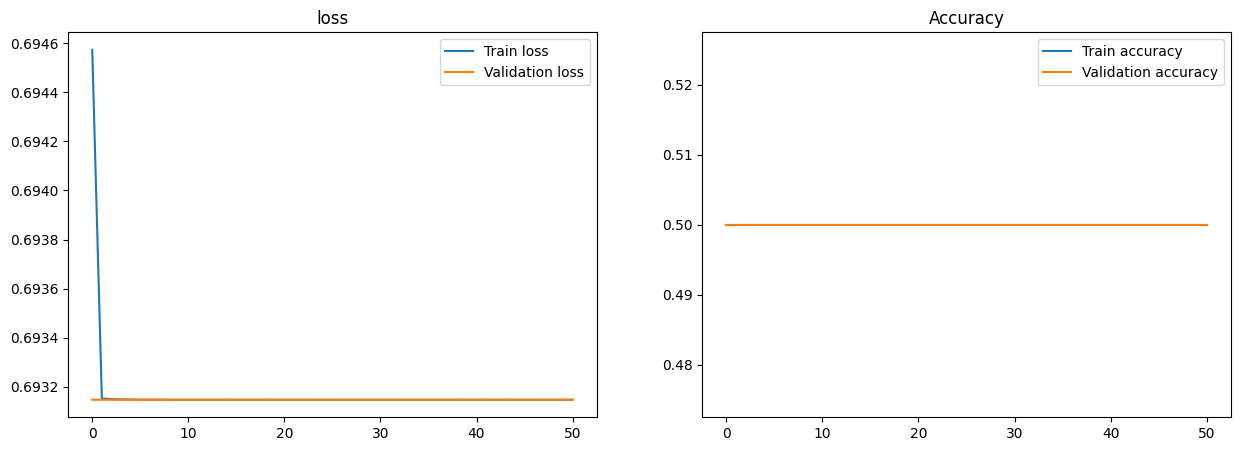

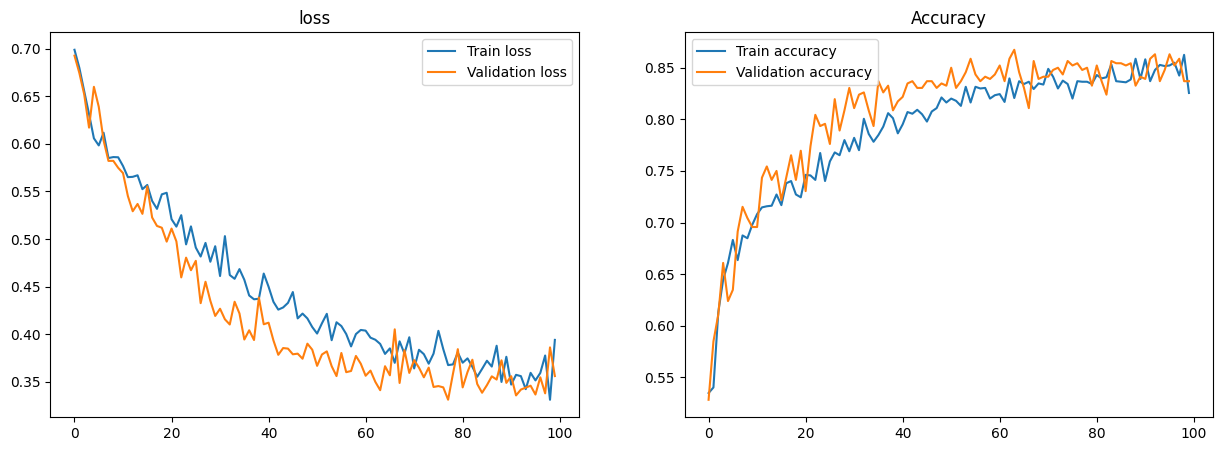

In [103]:
for history in histories:
    show_final_history(history)

1/1 [==============================] - 0s 18ms/step


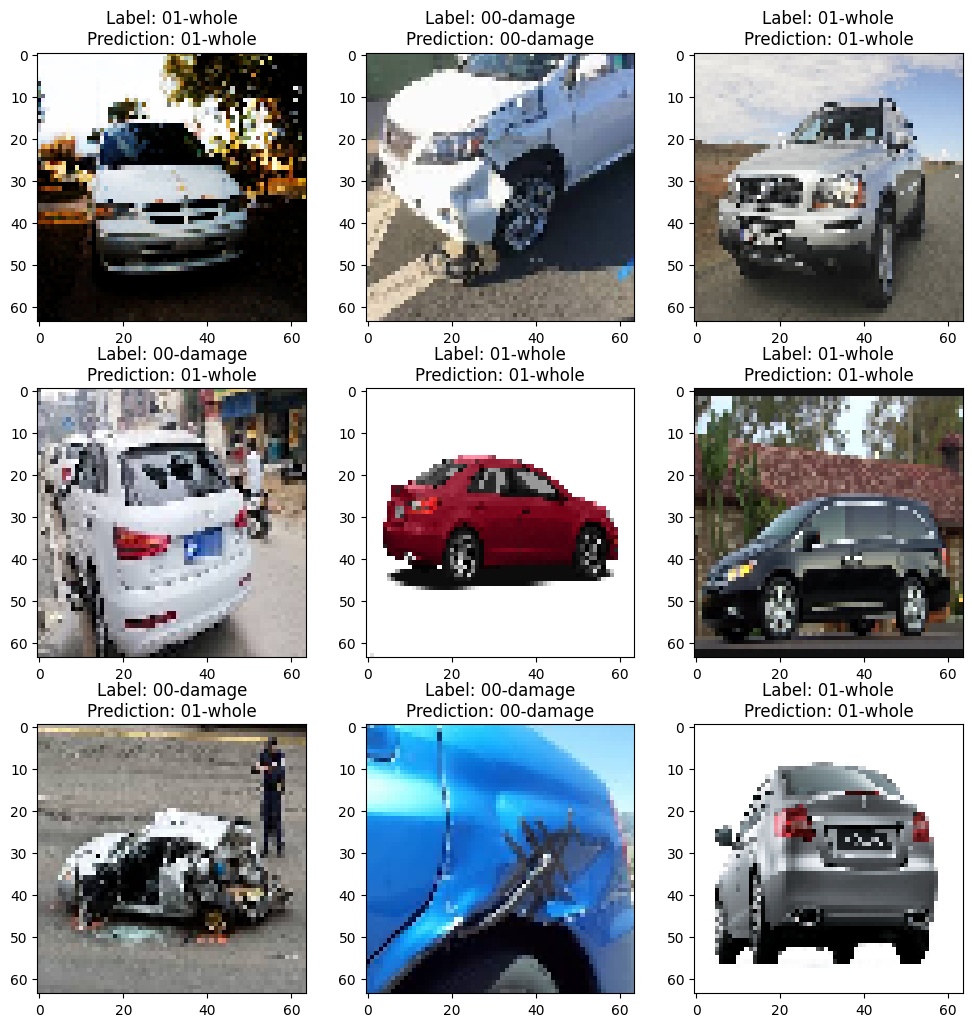

In [ ]:
labels = ['00-damage','01-whole']
it = iter(testing_set)

batch = next(it)
fig,axes = plt.subplots(3,3, figsize = (10,10))
fig.tight_layout()
fig.subplots_adjust(hspace = 0.25)

for i in range(3):
    for j in range(3):
        ax = axes[i,j]
        image = batch[0][i*3 +j]
        net_input = image.reshape((1,64,64,3))
        truth = np.argmax(batch[1][i*3+j])
        prediction = np.argmax(model.predict(net_input))
        ax.set_title('Label: %s\nPrediction: %s' % (labels[truth].capitalize(),labels[prediction].capitalize()))
        ax.imshow(image)

In [ ]:
def custom_predictions(path):
    img = ig.load_img(path, target_size = (64,64))
    plt.imshow(img)

    img = np.expand_dims(img, axis = 0)
    img.reshape(1,64,64,3)
    prediction = np.argmax(model.predict(img))
    plt.title(labels[prediction])

    plt.show()

1/1 [==============================] - 0s 49ms/step


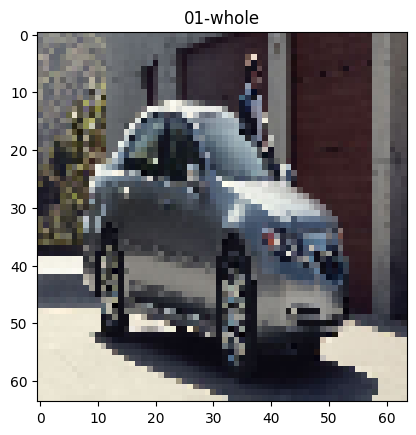

In [ ]:
custom_predictions('/content/drive/MyDrive/Colab Notebooks/data1a/training/01-whole/0007.jpg')